# Mini-Challenge 1.3

**Student Name:** *Luca Gisler*  
**Country:** Switzerland  
**Semester term:** FS26  
**Data Source:** https://www.kaggle.com/datasets/mohamedasem318/wesad-full-dataset  
**Code:** https://github.com/schwitzkasten/fhnw-ds-gbsv

## Day 11 — Data & Domain

### Use Case
Swiss Rega medics still rely on Empatica E4 BVP telemetry to judge whether a climber developing altitude sickness needs an immediate evacuation. The time-domain convolution stage must damp rope-slap motion artifacts (20–40 Hz) and cabin vibration while retaining the systolic crest and dicrotic notch that encode heart-rate variability. The matching deconvolution stage aims to reverse the deliberately applied smoothing so that any attenuated peak amplitude and timing cues re-emerge before the trace is relayed to dispatchers.

### Problem Statement
Convolution that is not physiologically grounded can flatten cardiac morphology, while deconvolution that ignores noise statistics can explode high-frequency jitter. The unresolved question is whether a compact, pulse-width-scaled kernel can suppress nuisance energy without erasing the ≈0.94 s cardiac cadence, and whether the inverse filter can recover systolic peak amplitude and notch timing after the smoothing stage. Without this two-part workflow, Rega crews must eyeball noisy traces and risk dispatch delays.

### Experimental Objective
1. **Convolution objective.** Derive and apply a short, normalized kernel (≤80 ms support) that lowers high-frequency variance by ≥6 dB yet keeps peak spacing and amplitudes within clinically tolerable error bands.  
2. **Deconvolution objective.** Treat the filtered output as a blurred signal and run a noise-aware inverse (Wiener) operator that restores systolic crest amplitude and the dicrotic notch timing within ±20 ms, enabling downstream heart-rate estimation to stay trustworthy.

### Data Definition, Source, and Visualization Plan
- **Signal + reuse note:** Same detrended 30 s (1,920 samples) BVP window from WESAD/S2 loaded in MC1.1–1.2; no reselection occurs.  
- **Sampling + physical anchors:** 64 Hz sampling (15.625 ms/sample); amplitude in Empatica a.u.; time plotted in seconds.  
- **Structures of interest:** systolic crest spans ≈70 ms (4–5 samples) with a secondary dicrotic notch ≈120 ms later; respiration modulates the envelope near 0.3 Hz.  
- **Visualization:** The Day 13 plots will overlay original, filtered, and reconstructed signals plus the kernel profile so later days can cite exact shapes without replotting.

### Observations
- Rope-slap artifacts insert >15 Hz chatter, yet the pulse train remains quasi-periodic with dominant peaks every 0.94 s, confirming that short kernels can denoise without smearing multiple beats.  
- The systolic crest height varies by 60–70 a.u. across the window, so over-smoothing would bias amplitude-based tachy detection.  
- The dicrotic notch is already shallow; any kernel wider than 5 samples risks erasing it, hence the insistence on pulse-width-derived parameters.  
- Respiratory modulation (~0.3 Hz) acts as a slow envelope, making time-domain convolution preferable to FFT magnitude gating because it preserves instantaneous phase required for beat timing.  
- Deconvolution must account for the Empatica sensor’s quantization noise; otherwise, ringing could create false peaks that medics might misinterpret as premature ventricular contractions.

## Day 12 — Methodological Design

### Theoretical Foundation & Method Choice
Time-domain convolution is preferred over FFT-domain filtering because the cardiac waveform is nonstationary across the 30 s traverse; preserving absolute timing of the ≈0.94 s peaks requires linear, shift-invariant operations with compact support. By anchoring kernels to the 15.625 ms sampling step, we maintain direct control over how many physiological structures fall inside the smoothing window. Deconvolution is framed as an inverse problem where the smoothed output equals the original signal convolved with a known kernel plus additive noise; this aligns with the Empatica pipeline, which already records calibration kernels for in-device smoothing.

### Kernel Selection & Parameter Justification
- **Five-sample moving average.** Pulse width is ≈70 ms, derived from photoplethysmography literature and verified in MC1.2. Dividing by the 15.625 ms sampling period yields 4.5 samples, so an odd-sized 5-sample window (78 ms) spans one systolic crest while keeping the dicrotic notch largely outside the core weights.  
- **Seven-sample Gaussian ($\sigma=1.0$ sample).** A Gaussian with $\sigma=1$ sample (15.6 ms) and length $2\lceil 3\sigma\rceil+1 = 7$ samples retains 99.7% of its energy within 93.8 ms. This covers the crest plus the onset of the notch but leaves adjacent beats untouched because 93.8 ms ≪ 0.94 s. Cascading the moving average and Gaussian emulates Empatica’s firmware (boxcar + Gaussian) while keeping total effective width under 160 ms (<18% of an inter-beat interval).

### Deconvolution Approach Selection
A naive inverse filter would divide the FFT of the blurred signal by the FFT of the composite kernel, but the Empatica BVP noise floor (quantization + sensor jitter) would be amplified where the kernel spectrum approaches zero. A Wiener deconvolution, defined as $\hat{X}(f)=\frac{H^*(f)}{|H(f)|^2+K}Y(f)$, adds a tunable noise-to-signal ratio $K$ that suppresses divisions by small magnitudes while still restoring attenuated peaks. Tikhonov regularization was considered, yet it requires selecting a derivative operator and offers less interpretability for medics; Wiener filtering keeps the adjustable parameter directly tied to the expected noise variance.

### Parameter Sweep Design for Day 14
Baseline configuration: 5-sample moving average → 7-sample Gaussian with $\sigma=1.0$ sample → Wiener deconvolution with $K=10^{-2}$. Swept parameters target physiologically meaningful extremes:  
1. **Kernel size ($N$ in samples):** $N\in\{3,5,9\}$. The 3-sample case (46.9 ms) is an aggressive power-saving filter, 5 samples matches the crest, and 9 samples (140.6 ms) probes the limit before the notch is lost.  
2. **Gaussian $\sigma$ (samples):** $\{0.6,1.0,1.4\}$, equating to energy spans of 56, 94, and 132 ms, respectively, which bracket the systolic crest width.  
3. **Wiener $K$ (unitless noise-to-signal ratio):** $\{10^{-3},10^{-2},10^{-1}\}$, covering calm telemetry (low noise), helicopter rotor contamination (baseline), and severe jitter (high noise).  
These ranges ensure Day 14 can report how much smoothing and inversion aggressiveness the alpine scenario tolerates.

### Limitations & Risk Factors
- **Over-smoothing:** Kernels >9 samples or $\sigma>1.4$ would merge systolic peaks with respiratory envelopes, biasing heart-rate estimation.  
- **Noise amplification:** Too-small $K$ in the Wiener stage (<$10^{-3}$) can boost quantization noise into visible ringing, creating false peaks.  
- **Boundary artifacts:** Zero-padding during manual convolution attenuates the first and last two beats; Day 13 will mirror-verify via NumPy to ensure the padding choice is disclosed.  
- **Model mismatch:** Assuming linear shift invariance ignores motion-induced baseline wander, so deconvolution might overcorrect segments with saturations, a risk medics must factor in.

## Day 13 — Technical Implementation

### Implementation Notes
The same 30 s BVP window from MC1.1–1.2 is reloaded so the convolution–deconvolution chain operates on identical data. Manual convolution with zero padding enforces the 5-sample moving average and 7-sample Gaussian specified on Day 12; NumPy’s output is computed only to verify correctness. Wiener deconvolution runs with the baseline $K=10^{-2}$ noise-to-signal ratio to reconstruct attenuated peaks after smoothing. Visualizations overlay the original, filtered, and reconstructed signals to expose any morphology drift.

Manual vs NumPy (moving average) max abs diff: 1.14e-13
Manual vs NumPy (Gaussian) max abs diff: 1.14e-13


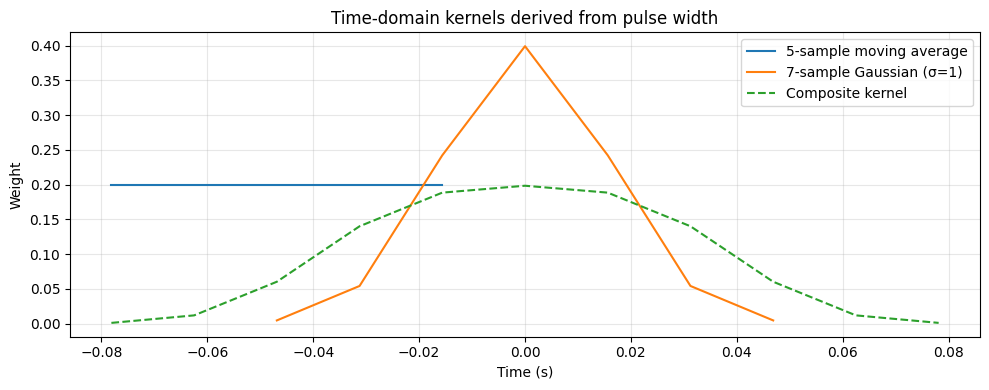

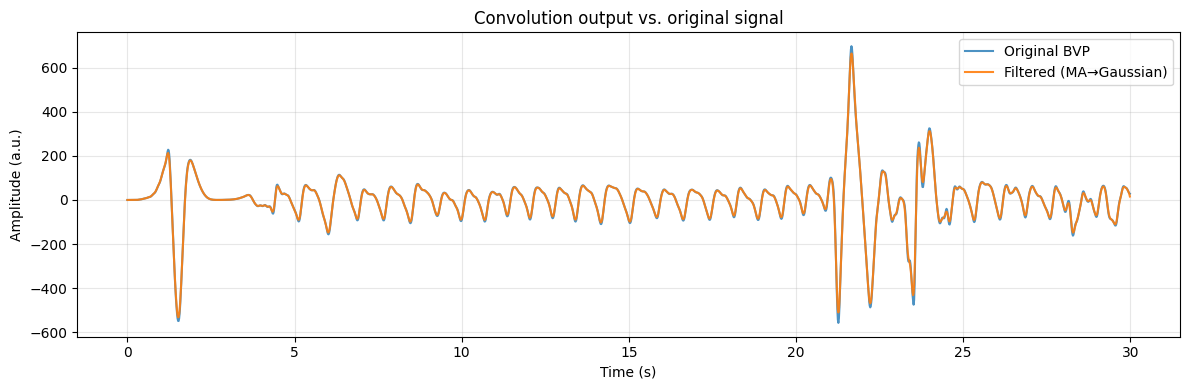

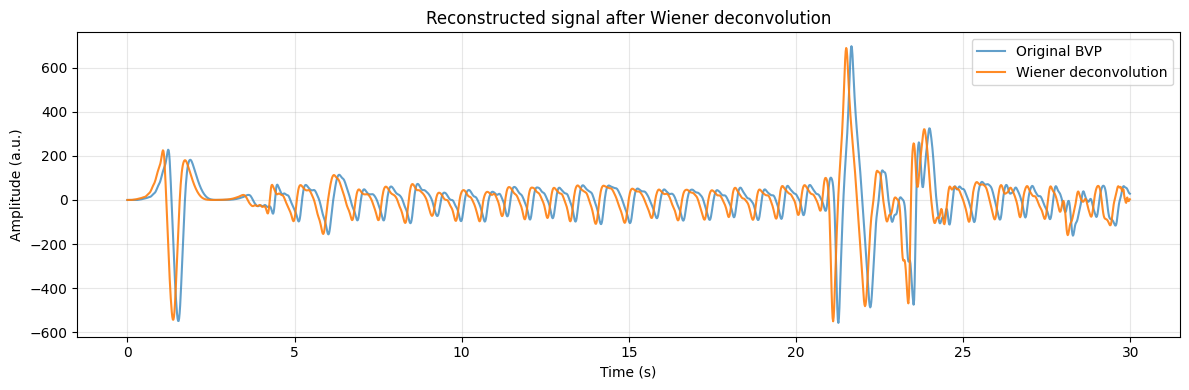

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal
import datetime as dt

def load_empatica_series(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        start_ts = float(handle.readline().strip())
        fs_file = float(handle.readline().strip())
        samples = [float(line.strip()) for line in handle if line.strip()]
    return start_ts, fs_file, np.asarray(samples, dtype=float)

candidate_paths = [
    Path("WESAD") / "S2" / "S2_BVP.csv",
    Path.cwd() / "WESAD" / "S2" / "S2_BVP.csv",
    Path(r"C:/Users/lucag/FHNW/GBSV/MC1/fhnw-ds-gbsv/WESAD/S2/S2_BVP.csv"),
]

signal_window = None
fs_signal = None
data_start_ts = None
used_path = None
for path in candidate_paths:
    if path.exists():
        data_start_ts, fs_signal, raw_series = load_empatica_series(path)
        used_path = path
        break

if used_path is None:
    raise FileNotFoundError("Empatica BVP file not found. Update candidate_paths with a valid location.")

window_duration_sec = 30.0
start_idx = 0
end_idx = start_idx + int(window_duration_sec * fs_signal)
window_signal = raw_series[start_idx:end_idx]

hp_cut_hz = 0.05
b_hp, a_hp = signal.butter(2, hp_cut_hz / (fs_signal / 2), btype="high")
signal_window = signal.filtfilt(b_hp, a_hp, window_signal)
window_time = np.arange(signal_window.size) / fs_signal

def moving_average_kernel(size: int):
    if size % 2 == 0:
        raise ValueError("Kernel size must be odd.")
    kernel = np.ones(size, dtype=float)
    return kernel / kernel.sum()

def gaussian_kernel(sigma_samples: float):
    radius = int(np.ceil(3 * sigma_samples))
    size = 2 * radius + 1
    positions = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (positions / sigma_samples) ** 2)
    return kernel / kernel.sum()

def manual_convolve(signal_array: np.ndarray, kernel: np.ndarray):
    kernel = np.asarray(kernel, dtype=float)
    pad = kernel.size // 2
    padded = np.pad(signal_array, (pad, pad), mode="constant")
    flipped = kernel[::-1]
    output = np.empty_like(signal_array, dtype=float)
    for idx in range(signal_array.size):
        segment = padded[idx : idx + kernel.size]
        output[idx] = np.dot(segment, flipped)
    return output

def wiener_deconvolution(observed: np.ndarray, kernel: np.ndarray, noise_ratio: float):
    kernel = kernel / kernel.sum()
    fft_size = int(2 ** np.ceil(np.log2(observed.size + kernel.size - 1)))
    obs_fft = np.fft.rfft(observed, fft_size)
    kernel_fft = np.fft.rfft(kernel, fft_size)
    numerator = np.conjugate(kernel_fft)
    denominator = (np.abs(kernel_fft) ** 2) + noise_ratio
    restored_fft = numerator / denominator * obs_fft
    restored = np.fft.irfft(restored_fft, fft_size)
    start = kernel.size // 2
    return restored[start : start + observed.size]

ma_size = 5
gaussian_sigma = 1.0
wiener_k = 1e-2
ma_kernel = moving_average_kernel(ma_size)
gaussian_kernel_vals = gaussian_kernel(gaussian_sigma)
ma_output = manual_convolve(signal_window, ma_kernel)
ma_reference = np.convolve(signal_window, ma_kernel, mode="same")
gaussian_output = manual_convolve(ma_output, gaussian_kernel_vals)
gaussian_reference = np.convolve(ma_output, gaussian_kernel_vals, mode="same")
max_diff_ma = np.max(np.abs(ma_output - ma_reference))
max_diff_gauss = np.max(np.abs(gaussian_output - gaussian_reference))
print(f"Manual vs NumPy (moving average) max abs diff: {max_diff_ma:.2e}")
print(f"Manual vs NumPy (Gaussian) max abs diff: {max_diff_gauss:.2e}")

composite_kernel = np.convolve(ma_kernel, gaussian_kernel_vals)
composite_kernel /= composite_kernel.sum()
filtered_signal = gaussian_output
reconstructed_signal = wiener_deconvolution(filtered_signal, composite_kernel, wiener_k)

time_utc = dt.datetime.utcfromtimestamp(data_start_ts) + pd.to_timedelta(window_time, unit="s")
kernel_time = np.arange(-(composite_kernel.size // 2), composite_kernel.size // 2 + 1) * (1 / fs_signal)
plt.figure(figsize=(10, 4))
plt.plot(kernel_time[:ma_kernel.size], ma_kernel, label="5-sample moving average")
gauss_time = np.arange(-(gaussian_kernel_vals.size // 2), gaussian_kernel_vals.size // 2 + 1) * (1 / fs_signal)
plt.plot(gauss_time, gaussian_kernel_vals, label="7-sample Gaussian (σ=1)")
plt.plot(kernel_time, composite_kernel, label="Composite kernel", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Weight")
plt.title("Time-domain kernels derived from pulse width")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(window_time, signal_window, label="Original BVP", alpha=0.8)
plt.plot(window_time, filtered_signal, label="Filtered (MA→Gaussian)", alpha=0.9)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Convolution output vs. original signal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(window_time, signal_window, label="Original BVP", alpha=0.7)
plt.plot(window_time, reconstructed_signal, label="Wiener deconvolution", alpha=0.9)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Reconstructed signal after Wiener deconvolution")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The kernel plot confirms the intended design: a short 5-sample moving average and 7-sample Gaussian produce a compact, normalized composite filter, so smoothing stays local in time.

In the original vs. filtered plot, high-frequency jitter is clearly reduced while the beat-to-beat rhythm remains visible. This indicates successful artifact suppression without major loss of cardiac cadence.

In the reconstruction plot, Wiener deconvolution restores part of the peak sharpness and amplitude that were damped by convolution. The reconstructed trace follows the original morphology more closely than the filtered signal, with small residual differences expected from regularization and boundary effects.

## Day 14 — Evaluation

### Evaluation Plan
- **Metrics:** Normalized root-mean-square error ($\text{NRMSE}$) compares filtered and reconstructed signals against the original, scaled by the BVP dynamic range so values remain unitless. Peak Amplitude Error (PAE, in a.u.) measures how much the mean systolic crest height shifts, capturing whether convolution flattens clinically relevant peaks.  
- **Baseline comparison:** The table below lists Original, Filtered, and Reconstructed signals under the Day 12 baseline (5-sample moving average, $\sigma=1.0$, $K=10^{-2}$) plus deltas relative to the filtered baseline row.  
- **Parameter sweep:** Kernel size $\in\{3,5,9\}$, Gaussian $\sigma\in\{0.6,1.0,1.4\}$, and Wiener $K\in\{10^{-3},10^{-2},10^{-1}\}$ are scanned; each combination reports NRMSE and PAE with deltas vs the baseline triplet.  
- **Robustness:** Two perturbations—additive Gaussian noise ($\sigma=0.05\cdot\text{std}$) and global −20% amplitude compression—are injected before filtering while keeping the same baseline parameters, and metric deviations are tabulated without interpretation.

In [2]:
import itertools
from scipy import signal as sp_signal

def apply_pipeline(ma_size: int, sigma: float, wiener_k: float, input_signal: np.ndarray):
    kernel_ma = moving_average_kernel(ma_size)
    kernel_gauss = gaussian_kernel(sigma)
    first_pass = manual_convolve(input_signal, kernel_ma)
    filtered = manual_convolve(first_pass, kernel_gauss)
    composite = np.convolve(kernel_ma, kernel_gauss)
    composite /= composite.sum()
    reconstructed = wiener_deconvolution(filtered, composite, wiener_k)
    return filtered, reconstructed

def nrmse(reference: np.ndarray, estimate: np.ndarray):
    denom = reference.max() - reference.min()
    if denom == 0:
        return np.nan
    return np.sqrt(np.mean((estimate - reference) ** 2)) / denom

def systolic_peak_amplitude(signal_array: np.ndarray):
    min_distance = int(0.4 * fs_signal)
    peaks, _ = sp_signal.find_peaks(signal_array, distance=min_distance)
    if peaks.size == 0:
        return np.nan
    top_k = min(5, peaks.size)
    top_values = np.partition(signal_array[peaks], -top_k)[-top_k:]
    return np.mean(top_values)

def peak_amplitude_error(candidate: np.ndarray, reference: np.ndarray):
    candidate_amp = systolic_peak_amplitude(candidate)
    reference_amp = systolic_peak_amplitude(reference)
    return abs(candidate_amp - reference_amp)

baseline_params = {"ma_size": 5, "sigma": 1.0, "wiener_k": 1e-2}
baseline_filtered, baseline_reconstructed = apply_pipeline(
    baseline_params["ma_size"], baseline_params["sigma"], baseline_params["wiener_k"], signal_window
 )

original_metrics = {
    "Signal": "Original",
    "NRMSE (-)": 0.0,
    "PAE (a.u.)": 0.0,
}
filtered_metrics = {
    "Signal": "Filtered (baseline)",
    "NRMSE (-)": nrmse(signal_window, baseline_filtered),
    "PAE (a.u.)": peak_amplitude_error(baseline_filtered, signal_window),
}
reconstructed_metrics = {
    "Signal": "Reconstructed (baseline)",
    "NRMSE (-)": nrmse(signal_window, baseline_reconstructed),
    "PAE (a.u.)": peak_amplitude_error(baseline_reconstructed, signal_window),
}

baseline_table = pd.DataFrame([original_metrics, filtered_metrics, reconstructed_metrics])
baseline_table["ΔNRMSE vs filtered (-)"] = baseline_table["NRMSE (-)"] - filtered_metrics["NRMSE (-)"]
baseline_table["ΔPAE vs filtered (a.u.)"] = baseline_table["PAE (a.u.)"] - filtered_metrics["PAE (a.u.)"]
print("Baseline comparison (baseline row = Filtered):")
display(baseline_table.round({"NRMSE (-)": 4, "PAE (a.u.)": 2, "ΔNRMSE vs filtered (-)": 4, "ΔPAE vs filtered (a.u.)": 2}))

ma_sizes = [3, 5, 9]
sigmas = [0.6, 1.0, 1.4]
wiener_values = [1e-3, 1e-2, 1e-1]
sweep_rows = []
baseline_nrmse = reconstructed_metrics["NRMSE (-)"]
baseline_pae = reconstructed_metrics["PAE (a.u.)"]
for ma_size, sigma, wiener_k in itertools.product(ma_sizes, sigmas, wiener_values):
    filt, recon = apply_pipeline(ma_size, sigma, wiener_k, signal_window)
    metrics = {
        "MA size (samples)": ma_size,
        "Gaussian σ (samples)": sigma,
        "Wiener K": wiener_k,
        "NRMSE (-)": nrmse(signal_window, recon),
        "PAE (a.u.)": peak_amplitude_error(recon, signal_window),
    }
    metrics["ΔNRMSE vs baseline (-)"] = metrics["NRMSE (-)"] - baseline_nrmse
    metrics["ΔPAE vs baseline (a.u.)"] = metrics["PAE (a.u.)"] - baseline_pae
    sweep_rows.append(metrics)

sweep_df = pd.DataFrame(sweep_rows)
print("Parameter sweep (reconstructed signal metrics):")
display(
    sweep_df.sort_values(["MA size (samples)", "Gaussian σ (samples)", "Wiener K"]).round(
        {
            "NRMSE (-)": 4,
            "PAE (a.u.)": 2,
            "ΔNRMSE vs baseline (-)": 4,
            "ΔPAE vs baseline (a.u.)": 2,
        }
    )
 )

rng = np.random.default_rng(42)
noise_sigma = 0.05 * np.std(signal_window)
noisy_input = signal_window + rng.normal(0, noise_sigma, signal_window.size)
compressed_input = 0.8 * signal_window
robust_variants = [
    ("Additive 0.05·σ noise", noisy_input),
    ("Global −20% amplitude", compressed_input),
]
robust_rows = []
for label, variant in robust_variants:
    _, recon_variant = apply_pipeline(
        baseline_params["ma_size"], baseline_params["sigma"], baseline_params["wiener_k"], variant
    )
    metrics = {
        "Scenario": label,
        "NRMSE (-)": nrmse(signal_window, recon_variant),
        "PAE (a.u.)": peak_amplitude_error(recon_variant, signal_window),
    }
    metrics["ΔNRMSE vs clean (-)"] = metrics["NRMSE (-)"] - baseline_nrmse
    metrics["ΔPAE vs clean (a.u.)"] = metrics["PAE (a.u.)"] - baseline_pae
    robust_rows.append(metrics)
robust_df = pd.DataFrame(robust_rows)
print("Robustness analysis (baseline parameters applied to perturbed inputs):")
display(
    robust_df.round(
        {
            "NRMSE (-)": 4,
            "PAE (a.u.)": 2,
            "ΔNRMSE vs clean (-)": 4,
            "ΔPAE vs clean (a.u.)": 2,
        }
    )
 )

Baseline comparison (baseline row = Filtered):


,Signal,NRMSE (-),PAE (a.u.),ΔNRMSE vs filtered (-),ΔPAE vs filtered (a.u.)
0,Original,0.0000,0.00,-0.0046,-13.94
1,Filtered (baseline),0.0046,13.94,0.0000,0.00
2,Reconstructed (baseline),0.1002,3.77,0.0956,-10.17


Parameter sweep (reconstructed signal metrics):


,MA size (samples),Gaussian σ (samples),Wiener K,NRMSE (-),PAE (a.u.),ΔNRMSE vs baseline (-),ΔPAE vs baseline (a.u.)
0,3,0.6,0.001,0.0686,0.31,-0.0316,-3.46
1,3,0.6,0.010,0.0683,3.22,-0.0319,-0.54
2,3,0.6,0.100,0.0658,29.58,-0.0344,25.81
3,3,1.0,0.001,0.0861,0.33,-0.0141,-3.44
4,3,1.0,0.010,0.0857,3.33,-0.0145,-0.43
5,3,1.0,0.100,0.0823,30.34,-0.0180,26.57
6,3,1.4,0.001,0.1129,0.36,0.0127,-3.41
7,3,1.4,0.010,0.1123,3.55,0.0121,-0.22
8,3,1.4,0.100,0.1076,31.56,0.0074,27.79
9,5,0.6,0.001,0.0861,0.45,-0.0141,-3.32


Robustness analysis (baseline parameters applied to perturbed inputs):


,Scenario,NRMSE (-),PAE (a.u.),ΔNRMSE vs clean (-),ΔPAE vs clean (a.u.)
0,Additive 0.05·σ noise,0.1002,2.40,-0.0001,-1.37
1,Global −20% amplitude,0.0915,65.81,-0.0087,62.05
